# Ahora vamos a trabajar con los datos de DESI DR2

In [26]:
#librerías importantes
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

In [27]:
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",        # 'cm', 'stix', 'stixsans', 'dejavusans'
    "font.serif": ["STIXGeneral", "Times New Roman"],
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "figure.figsize": (8,5)
})

In [28]:
data = {
    "Tracer": ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", "Lya"],
    "z_eff": [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330],
    "DV/rd": [7.942, 12.720, 16.050, 19.721, 24.252, 26.055, 31.267],
    "sigma_DV/rd": [0.075, 0.099, 0.110, 0.091, 0.174, 0.398, 0.256],
    "DM/DH": [None, 0.622, 0.892, 1.223, 1.948, 2.386, 4.518],
    "sigma_DM/DH": [None, 0.017, 0.021, 0.019, 0.045, 0.136, 0.097],
    "r_V,M/H": [None, 0.050, -0.018, 0.056, 0.202, 0.044, 0.574],
    "DM/rd": [None, 13.588, 17.351, 21.576, 27.601, 30.512, 38.988],
    "sigma_DM/rd": [None,0.167, 0.177, 0.152, 0.318, 0.760, 0.531],
    "DH/rd": [None, 21.863, 19.455, 17.641, 14.176, 12.817, 8.632],
    "sigma_DH/rd": [None,0.425, 0.330, 0.193, 0.221, 0.516, 0.101],
    "r_M,H": [None, -0.459, -0.404, -0.416, -0.434, -0.500, -0.431]
}

df = pd.DataFrame(data)
print(df)


      Tracer  z_eff   DV/rd  sigma_DV/rd  DM/DH  sigma_DM/DH  r_V,M/H   DM/rd  \
0        BGS  0.295   7.942        0.075    NaN          NaN      NaN     NaN   
1       LRG1  0.510  12.720        0.099  0.622        0.017    0.050  13.588   
2       LRG2  0.706  16.050        0.110  0.892        0.021   -0.018  17.351   
3  LRG3+ELG1  0.934  19.721        0.091  1.223        0.019    0.056  21.576   
4       ELG2  1.321  24.252        0.174  1.948        0.045    0.202  27.601   
5        QSO  1.484  26.055        0.398  2.386        0.136    0.044  30.512   
6        Lya  2.330  31.267        0.256  4.518        0.097    0.574  38.988   

   sigma_DM/rd   DH/rd  sigma_DH/rd  r_M,H  
0          NaN     NaN          NaN    NaN  
1        0.167  21.863        0.425 -0.459  
2        0.177  19.455        0.330 -0.404  
3        0.152  17.641        0.193 -0.416  
4        0.318  14.176        0.221 -0.434  
5        0.760  12.817        0.516 -0.500  
6        0.531   8.632        0.101 

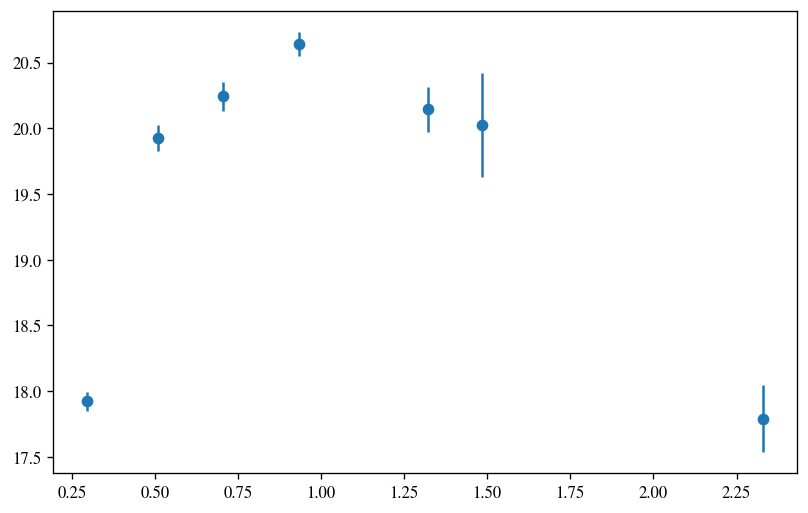

In [29]:
_=plt.errorbar(df['z_eff'],df['DV/rd']*df['z_eff']**(-2/3),df['sigma_DV/rd'],fmt='o')


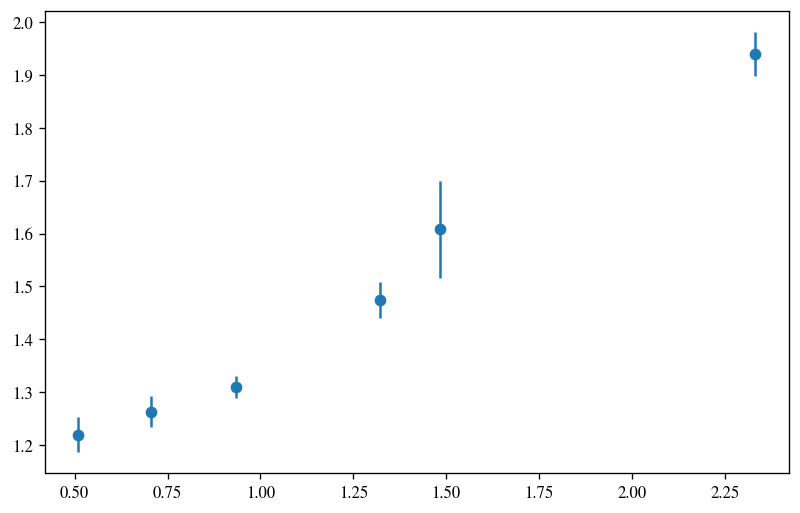

In [30]:
_= plt.errorbar(df['z_eff'],df['DM/DH']/df['z_eff'],df['sigma_DM/DH']/df['z_eff'],fmt='o')

In [31]:
from astropy.cosmology import Planck18, FlatLambdaCDM
import astropy.units as u
import astropy.constants as const

# Puedes usar un modelo predefinido:
cosmo = Planck18   # parámetros cosmológicos del Planck 2018

# O definir el tuyo:
#cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

z = 0.5

# Distancias disponibles:
Dc = cosmo.comoving_distance(z)        # distancia comóvil [Mpc]
Da = cosmo.angular_diameter_distance(z) # distancia angular [Mpc]
Dl = cosmo.luminosity_distance(z)       # distancia de luminosidad [Mpc]
Dh = cosmo.hubble_distance              # c / H0  [Mpc]
print(Dc, Da, Dl, Dh)


1946.4166347871185 Mpc 1297.611089858079 Mpc 2919.6249521806776 Mpc 4430.866952409105 Mpc


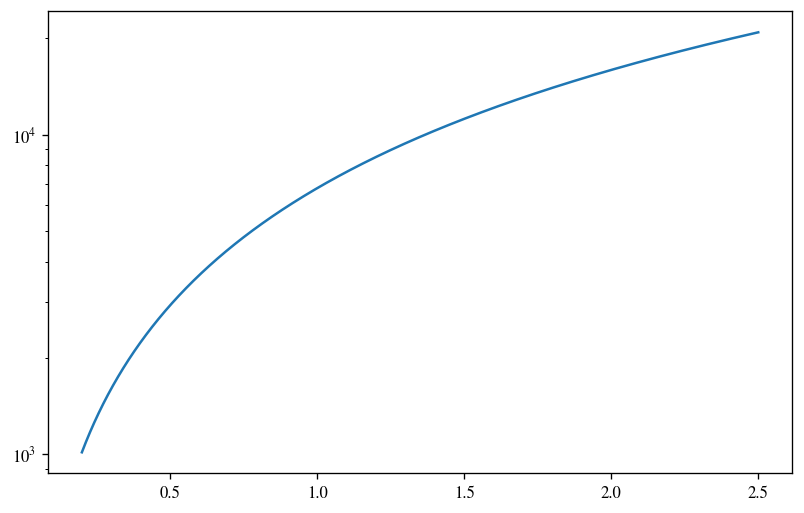

In [32]:
z = np.linspace(0.2,2.5,10000)
#_= plt.plot(z,cosmo.comoving_distance(z))
#_ = plt.plot(z,cosmo.angular_diameter_distance(z))
_ = plt.plot(z,cosmo.luminosity_distance(z))
#_ = plt.xscale('log')
_ = plt.yscale('log')

In [33]:
# --- Cálculos ---
# Distancia comóvil transversal D_M
D_M = lambda z:cosmo.comoving_transverse_distance(z)  # en Mpc

# Distancia de Hubble D_H = c / H(z)
D_H = lambda z:(const.c / cosmo.H(z)).to(u.Mpc)

# Distancia combinada (esférica) D_V = [ D_M^2 * cz/H(z) ]^(1/3)
D_V = lambda z: ((D_M(z)**2 * (const.c * z / cosmo.H(z)).to(u.Mpc)).value) ** (1/3) * u.Mpc


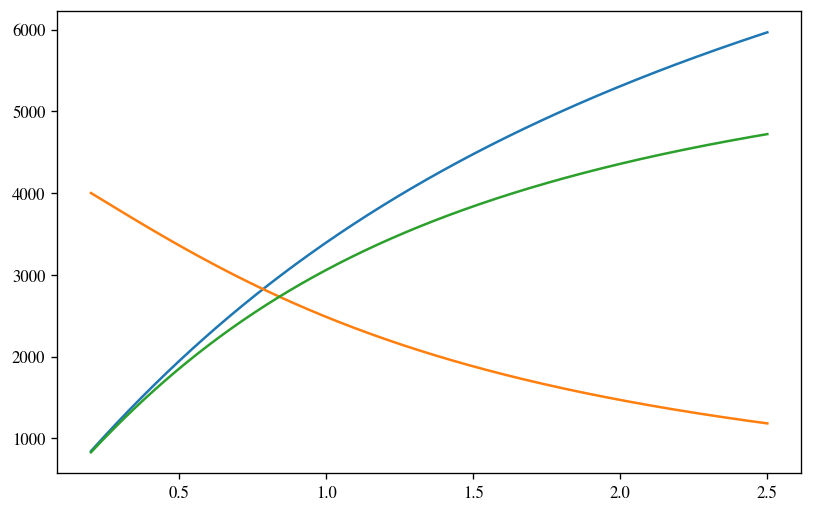

In [34]:
_ = plt.plot(z,D_M(z))
_ = plt.plot(z,D_H(z))
_ = plt.plot(z,D_V(z))

In [35]:
r_d = 147.09 * u.Mpc
print(r_d)

147.09 Mpc


In [36]:
colors = ['#C39BD3', '#F7DC6F', '#EF91CB', '#48C9B0', '#98FB98', '#FA8072', '#3498DB']

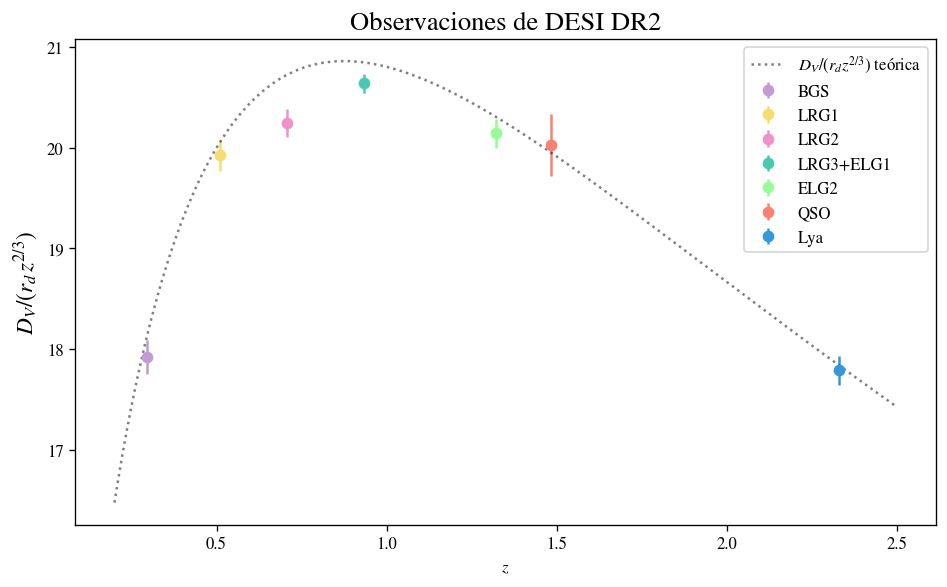

In [37]:
plt.figure(figsize=(8,5))
for i in range(len(df)):
    plt.errorbar(
        df['z_eff'][i],
        df['DV/rd'][i] * df['z_eff'][i]**(-2/3),
        df["z_eff"][i]**(-2/3) * df["sigma_DV/rd"][i],
        fmt='o',
        color=colors[i],
        label = df['Tracer'][i]
    )
plt.plot(z,D_V(z)/(r_d*(z**(2/3))),linestyle = 'dotted',color='black',alpha=0.5,label = '$D_V / (r_d z^{2/3})$ teórica')
plt.legend()
plt.xlabel("$z$")
plt.ylabel(r"$ D_V/(r_d\,z^{2/3})$", fontsize=14)
plt.title("Observaciones de DESI DR2",fontsize=16)
plt.tight_layout()
plt.show()

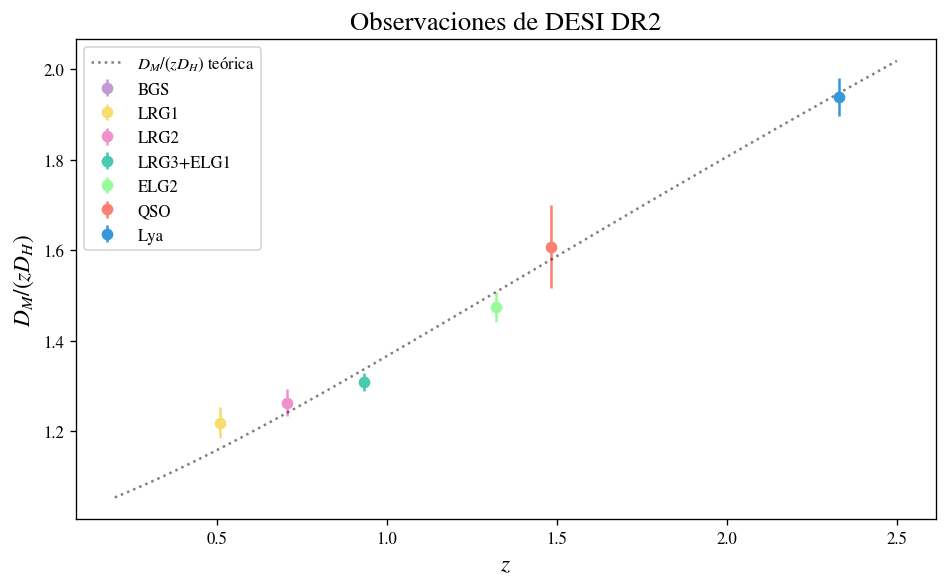

In [38]:
plt.figure(figsize=(8,5))
for i in range(len(df)):
    plt.errorbar(
        df['z_eff'][i],
        df['DM/DH'][i] / df['z_eff'][i],
        df['sigma_DM/DH'][i] / df['z_eff'][i],
        fmt='o',
        color=colors[i],
        label = df['Tracer'][i]
        )

plt.plot(z,D_M(z)/(z*D_H(z)),linestyle = 'dotted',color='black',alpha = 0.5, label = '$D_M / (z D_H )$ teórica')
plt.legend()
plt.xlabel("$z$",fontsize =14)
plt.ylabel(r"$D_M / (z D_H )$",fontsize = 14)
plt.title("Observaciones de DESI DR2",fontsize= 16)
plt.tight_layout()
plt.show()

Ahora construyamos el GP para las distancias cosmológicas

Primero vamos a hacer el gaussian sobre D_V

In [39]:
z_obs = np.array(df['z_eff'])
D_V_obs = np.zeros(len(df))
for i in range(len(df)):
    D_V_obs[i] = df['DV/rd'][i] * df['z_eff'][i]**(-2/3)

In [40]:
#matrices covarianza (errores)
#Sigma D_V
alpha = np.diag(np.array(df["z_eff"]**(-2/3) * df["sigma_DV/rd"]))
np.diag(alpha)


array([0.16924399, 0.15509165, 0.13873612, 0.09523797, 0.14452646,
       0.30591009, 0.14565856])

In [41]:
from sklearn.gaussian_process import kernels
from sklearn.gaussian_process import GaussianProcessRegressor

In [42]:
kernel = 1 * kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) #Se escoge el kernel y los hiperparámetros iniciales
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, alpha=np.diag(alpha)) #acá se hace la optimización (maximizando likelihood)
gaussian_process.fit(z_obs.reshape(-1, 1), D_V_obs) #esto se hace sobre las observaciones
gaussian_process.kernel_ #devuelve el kernel optimizado

14.3**2 * RBF(length_scale=1.79)

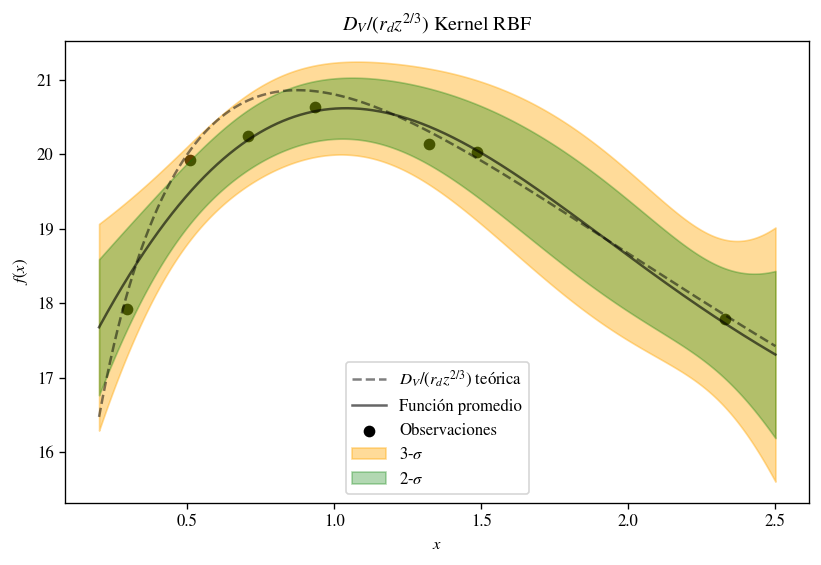

In [43]:
#Ahora vamos a sacar la mean function y los intervalos de confianza

mean_prediction, std_prediction = gaussian_process.predict(z.reshape(-1,1), return_std=True) #Se hace sobre los datos de entrenamiento (las t_star o tiempos predictivos)

plt.figure(figsize=(8,5))
plt.plot(z,D_V(z)/(r_d*(z**(2/3))),linestyle = 'dashed',color='black',alpha=0.5,label = '$D_V / (r_d z^{2/3})$ teórica')
plt.plot(z, mean_prediction, label="Función promedio",color='black',alpha=0.6) #Función sobre los datos de predicción que deben pasar sobre las observaciones
plt.scatter(z_obs, D_V_obs, color = 'black',label="Observaciones") #Puntos de observación

plt.fill_between(
    z.ravel(),
    mean_prediction - 2.98 * std_prediction,
    mean_prediction + 2.98 * std_prediction,
    alpha=0.4,color = 'orange',
    label=r"3-$\sigma$",
)
plt.fill_between(
    z.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.3,color = 'green',
    label=r"2-$\sigma$",
) #el fill between se hace sobre los t_star
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("$D_V / (r_d z^{2/3})$ Kernel RBF")
plt.show()

In [44]:
# Evaluación rápida del GP: métricas y diagnósticos
from scipy import stats
from sklearn.model_selection import KFold

In [45]:

def evaluate_gp(gp, X, y, y_err=None, n_folds=5, prefix="gp"):
    # predictions on training grid
    mu, std = gp.predict(X, return_std=True)
    if y_err is None:
        obs_var = std**2
    else:
        obs_var = std**2 + (y_err**2)
    resid = y - mu
    std_resid = resid / np.sqrt(obs_var)
    # metrics
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    # reduced chi2 (use number params as 1 if unknown)
    dof = max(len(y) - 1, 1)
    red_chi2 = np.sum((resid**2) / obs_var) / dof
    # log predictive density
    lpd = np.sum(stats.norm.logpdf(y, loc=mu, scale=np.sqrt(obs_var)))
    # coverage fractions
    cov1 = np.mean(np.abs(std_resid) <= 1.0)
    cov2 = np.mean(np.abs(std_resid) <= 2.0)
    cov3 = np.mean(np.abs(std_resid) <= 3.0)
    # LOO / K-fold CV for RMSE and mean log predictive density
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=0)
    rmses, lpds = [], []
    X_flat = X.reshape(-1,1)
    for train_idx, test_idx in kf.split(X_flat):
        gp_cv = type(gp)(kernel=gp.kernel_, alpha=gp.alpha[train_idx])  # recreate with same kernel/alpha
        gp_cv.fit(X_flat[train_idx], y[train_idx])
        mu_cv, std_cv = gp_cv.predict(X_flat[test_idx], return_std=True)
        var_cv = std_cv**2 + (y_err[test_idx]**2 if y_err is not None else 0)
        rmses.append(np.sqrt(np.mean((y[test_idx]-mu_cv)**2)))
        lpds.append(np.sum(stats.norm.logpdf(y[test_idx], loc=mu_cv, scale=np.sqrt(var_cv))))
    # summary
    out = {
        "rmse": rmse, "mae": mae, "reduced_chi2": red_chi2, "lpd": lpd,
        "coverage_1sigma": cov1, "coverage_2sigma": cov2, "coverage_3sigma": cov3,
        "cv_rmse_mean": np.mean(rmses), "cv_lpd_mean": np.mean(lpds),
        "std_resid": std_resid
    }
    # quick prints
    print(f"RMSE: {rmse:.4g}, MAE: {mae:.4g}, reduced-chi2: {red_chi2:.4g}")
    print(f"LPD: {lpd:.4g}, CV RMSE (mean): {out['cv_rmse_mean']:.4g}, CV LPD (mean): {out['cv_lpd_mean']:.4g}")
    print(f"Coverage: 1σ={cov1:.2%}, 2σ={cov2:.2%}, 3σ={cov3:.2%} (expected ≈68/95/99.7%)")
    return out

# Ejemplo de uso (ajusta nombres)
# X_train = z_obs_clean.reshape(-1,1)
# y_train = D_M_obs_clean
# y_err = sigma_DMDH_clean / z_obs_clean    # como construiste alpha
# metrics = evaluate_gp(gaussian_process2, X_train, y_train, y_err=y_err, n_folds=5, prefix="D_M")

# Diagnósticos visuales mínimos
def gp_diagnostics_plot(std_resid, X=None, savepath=None):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,4))
    plt.hist(std_resid, bins=12, density=True, alpha=0.6, label="std residuals")
    xs = np.linspace(-4,4,200)
    plt.plot(xs, stats.norm.pdf(xs), 'k--', label="N(0,1)")
    plt.legend(); plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=300)
    plt.show()
    # QQ
    plt.figure(figsize=(5,5))
    stats.probplot(std_resid, dist="norm", plot=plt)
    plt.tight_layout()
    if savepath: plt.savefig(savepath.replace(".png","_qq.png"), dpi=300)
    plt.show()

# Uso rápido tras llamar evaluate_gp:
# gp_out = evaluate_gp(gaussian_process2, X_train, y_train, y_err=y_err)
# gp_diagnostics_plot(gp_out["std_resid"], savepath="figs/gp_stdresid.png")

In [46]:
kernel = 1.0 * kernels.ExpSineSquared(
    length_scale=1.0,
    periodicity=3.0,
    length_scale_bounds=(0.1, 10.0),
    periodicity_bounds=(1.0, 10.0),
) #Se escoge el kernel y los hiperparámetros iniciales
gaussian_process = GaussianProcessRegressor(kernel=kernel, random_state=0,alpha=np.diag(alpha)) #acá se hace la optimización (maximizando likelihood)
gaussian_process.fit(z_obs.reshape(-1, 1), D_V_obs) #esto se hace sobre las observaciones
gaussian_process.kernel_ #devuelve el kernel optimizado

/Users/maryf/miniconda3/envs/macss/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


14.7**2 * ExpSineSquared(length_scale=10, periodicity=2.23)

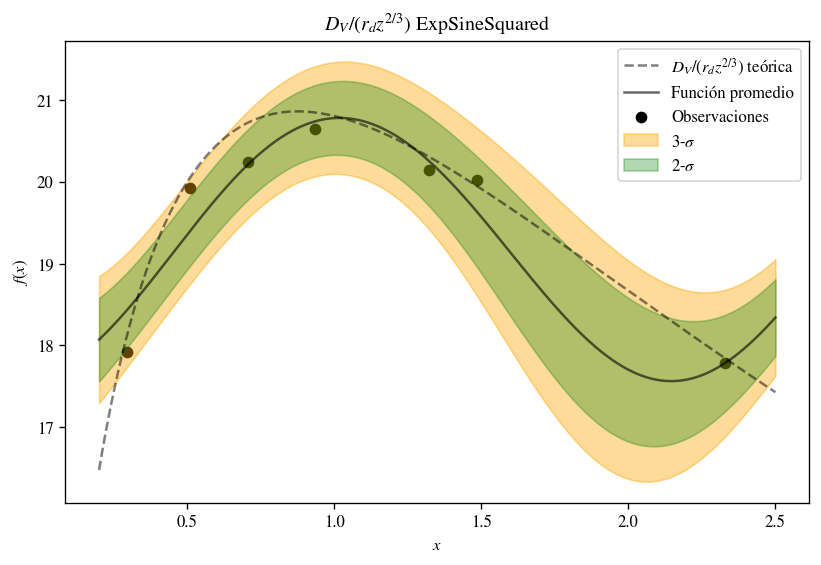

In [47]:
#Ahora vamos a sacar la mean function y los intervalos de confianza

mean_prediction, std_prediction = gaussian_process.predict(z.reshape(-1,1), return_std=True) #Se hace sobre los datos de entrenamiento (las t_star o tiempos predictivos)

plt.figure(figsize=(8,5))
plt.plot(z,D_V(z)/(r_d*(z**(2/3))),linestyle = 'dashed',color='black',alpha=0.5,label = '$D_V / (r_d z^{2/3})$ teórica')
plt.plot(z, mean_prediction, label="Función promedio",color='black',alpha=0.6) #Función sobre los datos de predicción que deben pasar sobre las observaciones
plt.scatter(z_obs, D_V_obs, color = 'black',label="Observaciones") #Puntos de observación

plt.fill_between(
    z.ravel(),
    mean_prediction - 2.98 * std_prediction,
    mean_prediction + 2.98 * std_prediction,
    alpha=0.4,color = 'orange',
    label=r"3-$\sigma$",
)
plt.fill_between(
    z.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.3,color = 'green',
    label=r"2-$\sigma$",
) #el fill between se hace sobre los t_star
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("$D_V / (r_d z^{2/3})$ ExpSineSquared")
plt.show()

In [48]:
kernel = 1* kernels.Matern(length_scale=1.0,length_scale_bounds=(1e-2, 1e2))
#Se escoge el kernel y los hiperparámetros iniciales
gaussian_process = GaussianProcessRegressor(kernel=kernel, random_state=0,alpha=np.diag(alpha)) #acá se hace la optimización (maximizando likelihood)
gaussian_process.fit(z_obs.reshape(-1, 1), D_V_obs) #esto se hace sobre las observaciones
gaussian_process.kernel_ #devuelve el kernel optimizado

14.2**2 * Matern(length_scale=5.15, nu=1.5)

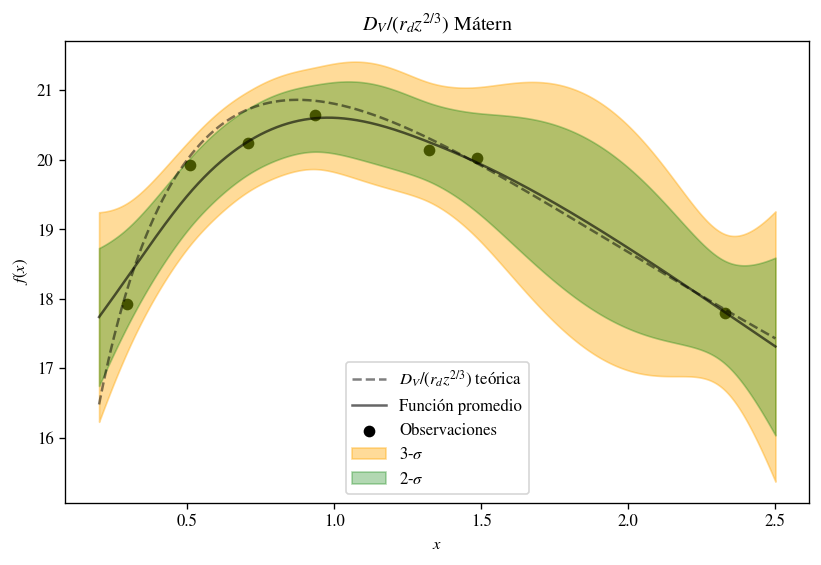

In [49]:
#Ahora vamos a sacar la mean function y los intervalos de confianza

mean_prediction, std_prediction = gaussian_process.predict(z.reshape(-1,1), return_std=True) #Se hace sobre los datos de entrenamiento (las t_star o tiempos predictivos)

plt.figure(figsize=(8,5))
plt.plot(z,D_V(z)/(r_d*(z**(2/3))),linestyle = 'dashed',color='black',alpha=0.5,label = '$D_V / (r_d z^{2/3})$ teórica')
plt.plot(z, mean_prediction, label="Función promedio",color='black',alpha=0.6) #Función sobre los datos de predicción que deben pasar sobre las observaciones
plt.scatter(z_obs, D_V_obs, color = 'black',label="Observaciones") #Puntos de observación

plt.fill_between(
    z.ravel(),
    mean_prediction - 2.98 * std_prediction,
    mean_prediction + 2.98 * std_prediction,
    alpha=0.4,color = 'orange',
    label=r"3-$\sigma$",
)
plt.fill_between(
    z.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.3,color = 'green',
    label=r"2-$\sigma$",
) #el fill between se hace sobre los t_star
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("$D_V / (r_d z^{2/3})$ Mátern")
plt.show()

Ahora trabajemos con D_M/r_d

In [50]:
D_M_obs = np.zeros(len(df))
for i in range(len(df)):
    D_M_obs[i] = df['DM/DH'][i] / df['z_eff'][i]

print(D_M_obs)

[       nan 1.21960784 1.26345609 1.30942184 1.47464042 1.60781671
 1.93905579]


In [51]:
mask = ~np.isnan(D_M_obs)            # True para valores válidos
z_obs_clean = z_obs[mask]
D_M_obs_clean = D_M_obs[mask]
sigma_DMDH_clean = np.array(df['sigma_DM/DH'])[mask]


In [52]:
#matrices covarianza (errores)
#Sigma D_V
alpha = np.diag(sigma_DMDH_clean / z_obs_clean)
np.diag(alpha)

array([0.03333333, 0.02974504, 0.02034261, 0.0340651 , 0.0916442 ,
       0.0416309 ])

In [53]:
kernel = 1.0 * kernels.ExpSineSquared(
    length_scale=1.0,
    periodicity=3.0,
    length_scale_bounds=(0.1, 10.0),
    periodicity_bounds=(1.0, 10.0),
) #Se escoge el kernel y los hiperparámetros iniciales
gaussian_process = GaussianProcessRegressor(kernel=kernel, random_state=0,alpha=np.diag(alpha)) #acá se hace la optimización (maximizando likelihood)

#kernel = kernels.DotProduct(sigma_0=1.0, sigma_0_bounds=(0.1, 10.0))

#kernel = kernels.DotProduct(sigma_0=0.1) + kernels.WhiteKernel(noise_level=0.1)
#gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
#gaussian_process = GaussianProcessRegressor(kernel=kernel, random_state=0, normalize_y=True)
gaussian_process.fit(z_obs_clean.reshape(-1, 1), D_M_obs_clean) #esto se hace sobre las observaciones
gaussian_process.kernel_ #devuelve el kernel optimizado

/Users/maryf/miniconda3/envs/macss/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__periodicity is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


1.64**2 * ExpSineSquared(length_scale=2.96, periodicity=10)

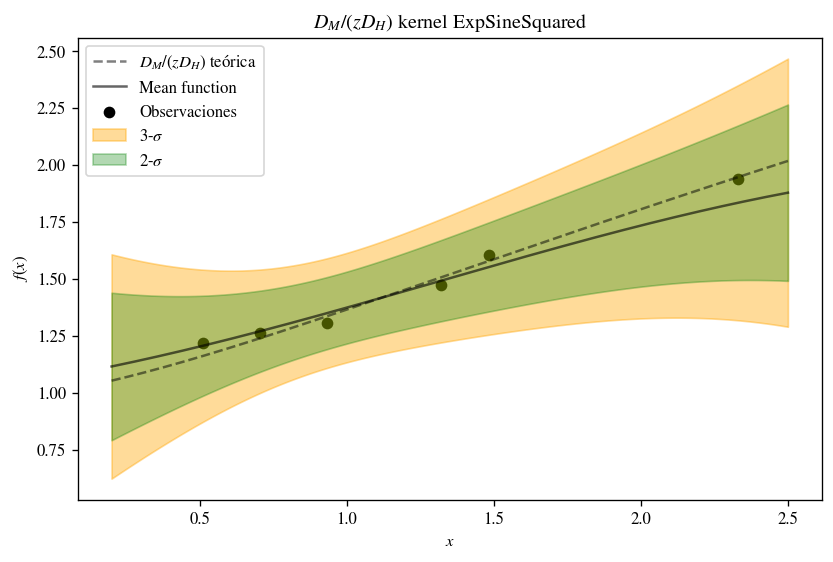

In [54]:
#Ahora vamos a sacar la mean function y los intervalos de confianza

mean_prediction, std_prediction = gaussian_process.predict(z.reshape(-1,1), return_std=True) #Se hace sobre los datos de entrenamiento (las t_star o tiempos predictivos)

plt.figure(figsize=(8,5))
plt.plot(z,D_M(z)/(z*D_H(z)),linestyle = 'dashed',color='black',alpha = 0.5, label = '$D_M / (z D_H )$ teórica')
plt.plot(z, mean_prediction, label="Mean function",color='black',alpha=0.6) #Función sobre los datos de predicción que deben pasar sobre las observaciones
plt.scatter(z_obs_clean, D_M_obs_clean, color = 'black',label="Observaciones") #Puntos de observación

plt.fill_between(
    z.ravel(),
    mean_prediction - 2.98 * std_prediction,
    mean_prediction + 2.98 * std_prediction,
    alpha=0.4,color = 'orange',
    label=r"3-$\sigma$",
)
plt.fill_between(
    z.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.3,color = 'green',
    label=r"2-$\sigma$",
) #el fill between se hace sobre los t_star
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("$D_M/(zD_H)$ kernel ExpSineSquared")
plt.show()

In [55]:
kernel2 = 1 * kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) #Se escoge el kernel y los hiperparámetros iniciales
gaussian_process2 = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=9, alpha=np.diag(alpha)) #acá se hace la optimización (maximizando likelihood)
gaussian_process2.fit(z_obs_clean.reshape(-1, 1), D_M_obs_clean) #esto se hace sobre las observaciones
gaussian_process2.kernel_ #devuelve el kernel optimizado

1.67**2 * RBF(length_scale=4.79)

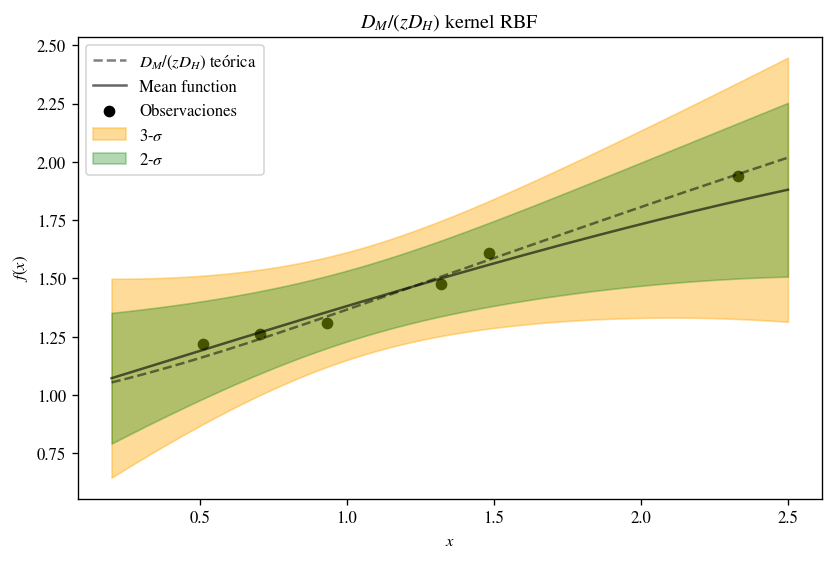

In [56]:
#Ahora vamos a sacar la mean function y los intervalos de confianza

mean_prediction2, std_prediction2 = gaussian_process2.predict(z.reshape(-1,1), return_std=True) #Se hace sobre los datos de entrenamiento (las t_star o tiempos predictivos)

plt.figure(figsize=(8,5))
plt.plot(z,D_M(z)/(z*D_H(z)),linestyle = 'dashed',color='black',alpha = 0.5, label = '$D_M / (z D_H )$ teórica')
plt.plot(z, mean_prediction2, label="Mean function",color='black',alpha=0.6) #Función sobre los datos de predicción que deben pasar sobre las observaciones
plt.scatter(z_obs_clean, D_M_obs_clean, color = 'black',label="Observaciones") #Puntos de observación

plt.fill_between(
    z.ravel(),
    mean_prediction2 - 2.98 * std_prediction2,
    mean_prediction2 + 2.98 * std_prediction2,
    alpha=0.4,color = 'orange',
    label=r"3-$\sigma$",
)
plt.fill_between(
    z.ravel(),
    mean_prediction2 - 1.96 * std_prediction2,
    mean_prediction2 + 1.96 * std_prediction2,
    alpha=0.3,color = 'green',
    label=r"2-$\sigma$",
) #el fill between se hace sobre los t_star
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("$D_M/(zD_H)$ kernel RBF")
plt.show()

In [57]:
kernel3 = 1* kernels.Matern(length_scale=1.0,length_scale_bounds=(1e-2, 1e2))
gaussian_process3 = GaussianProcessRegressor(kernel=kernel3, alpha=np.diag(alpha)) #acá se hace la optimización (maximizando likelihood)
gaussian_process3.fit(z_obs_clean.reshape(-1, 1), D_M_obs_clean) #esto se hace sobre las observaciones
gaussian_process3.kernel_ #devuelve el kernel optimizado

1.69**2 * Matern(length_scale=8.38, nu=1.5)

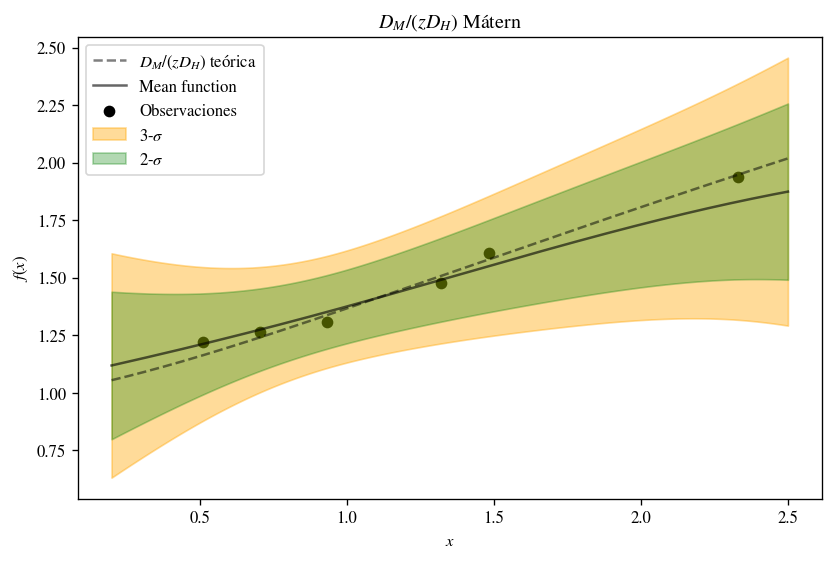

In [58]:
#Ahora vamos a sacar la mean function y los intervalos de confianza

mean_prediction3, std_prediction3 = gaussian_process3.predict(z.reshape(-1,1), return_std=True) #Se hace sobre los datos de entrenamiento (las t_star o tiempos predictivos)

plt.figure(figsize=(8,5))
plt.plot(z,D_M(z)/(z*D_H(z)),linestyle = 'dashed',color='black',alpha = 0.5, label = '$D_M / (z D_H )$ teórica')
plt.plot(z, mean_prediction3, label="Mean function",color='black',alpha=0.6) #Función sobre los datos de predicción que deben pasar sobre las observaciones
plt.scatter(z_obs_clean, D_M_obs_clean, color = 'black',label="Observaciones") #Puntos de observación

plt.fill_between(
    z.ravel(),
    mean_prediction3 - 2.98 * std_prediction3,
    mean_prediction3 + 2.98 * std_prediction3,
    alpha=0.4,color = 'orange',
    label=r"3-$\sigma$",
)
plt.fill_between(
    z.ravel(),
    mean_prediction3 - 1.96 * std_prediction3,
    mean_prediction3 + 1.96 * std_prediction3,
    alpha=0.3,color = 'green',
    label=r"2-$\sigma$",
) #el fill between se hace sobre los t_star
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("$D_M/(zD_H)$ Mátern")
plt.show()

In [59]:
#Definimos la likelihood

def log_likelihood_D_M(w0,wa,Omega_m,Omega_r,z_obs,D_M_obs,D_M_obserr):
    #las observaciones son los datos de DESI + los datos del GP
    #la teoría
    D_M_theory = lambda z:cosmo.comoving_transverse_distance(z) #acá tendría que usar los params cosmo
    chi_squared = sum(((D_M_obs - D_M_theory(z_obs)) / D_M_obserr)**2)
    log_likelihood = -0.5 * chi_squared
    return log_likelihood



def log_likelihood_D_V(w0,wa,Omega_m,Omega_r,z_obs,D_V_obs,D_V_obserr):
    #las observaciones son los datos de DESI + los datos del GP
    #la teoría
    D_M = lambda z:cosmo.comoving_transverse_distance(z) #acá tendría que usar los params cosmo
    D_V_theory = lambda z: ((D_M(z)**2 * (const.c * z / cosmo.H(z)).to(u.Mpc)).value) ** (1/3) * u.Mpc
    chi_squared = sum(((D_M_obs - D_V_theory(z_obs)) / D_V_obserr)**2)
    log_likelihood = -0.5 * chi_squared
    return log_likelihood

# Diagrama de Hubble

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from astroquery.mast import Observations
import astropy.io.fits as fits
from astropy.table import vstack
from scipy.optimize import curve_fit

from astropy.visualization import make_lupton_rgb
from astropy.wcs import WCS
import reproject

In [ ]:
eboss_data = Observations.query_criteria(
    obs_collection="SDSS",
    provenance_name="eBOSS",
    t_min=[58118, 60675],
    pagesize=5, #5 objetos
    page=1,
)

# Show the astropy table
eboss_data

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str4,str5,str4,str4,str4,str7,str21,str6,str27,float64,float64,str8,str18,int64,float64,float64,float64,float64,float64,str56,float64,str3,str1,int64,str56,str64,str64,str6,bool,float64,str9,str9
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 12547-58928-973,GALAXY,sdss_eboss_12547-58928-0973,140.84556,2.0501478,spectrum,SDSS Collaboration,3,58928.1631712963,58928.256680555554,7200.57,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 140.84556 2.0501478 0.0002777777777777778,mast:SDSS/eboss/12547/58928/0973/spec-image-12547-58928-0973.png,mast:SDSS/eboss/12547/58928/0973/full/spec-12547-58928-0973.fits,PUBLIC,False,nan,247912771,732063514
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 10726-58199-220,QSO,sdss_eboss_10726-58199-0220,249.00518,36.208064,spectrum,SDSS Collaboration,3,58199.39822916667,58199.43135497685,2700.26,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 249.00518 36.208064 0.0002777777777777778,mast:SDSS/eboss/10726/58199/0220/spec-image-10726-58199-0220.png,mast:SDSS/eboss/10726/58199/0220/full/spec-10726-58199-0220.fits,PUBLIC,False,nan,244936038,726560029
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 12545-58930-396,QSO,sdss_eboss_12545-58930-0396,139.8568,-0.69372933,spectrum,SDSS Collaboration,3,58930.18582175926,58930.24166770833,3600.35,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 139.8568 -0.69372933 0.0002777777777777778,mast:SDSS/eboss/12545/58930/0396/spec-image-12545-58930-0396.png,mast:SDSS/eboss/12545/58930/0396/full/spec-12545-58930-0396.fits,PUBLIC,False,nan,244721795,726082140
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 10911-58256-90,QSO,sdss_eboss_10911-58256-0090,250.7754,33.720196,spectrum,SDSS Collaboration,3,58254.430081018516,58256.40335706018,2700.18,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 250.7754 33.720196 0.0002777777777777778,mast:SDSS/eboss/10911/58256/0090/spec-image-10911-58256-0090.png,mast:SDSS/eboss/10911/58256/0090/full/spec-10911-58256-0090.fits,PUBLIC,False,nan,243753931,723973150
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 11063-58426-314,GALAXY,sdss_eboss_11063-58426-0314,14.22340300000002,6.2657629,spectrum,SDSS Collaboration,3,58426.256585648145,58426.32384340278,5400.47,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 14.22340300000002 6.2657629 0.0002777777777777778,mast:SDSS/eboss/11063/58426/0314/spec-image-11063-58426-0314.png,mast:SDSS/eboss/11063/58426/0314/full/spec-11063-58426-0314.fits,PUBLIC,False,nan,245059409,726828840


In [ ]:
# importing the galaxy IDs
obs_id = np.loadtxt("all_galaxies.txt", dtype=str)

# looping through the .txt file to collect query results
# (this might take a few minutes)
results_tables = []
for i in obs_id:
    query_result = Observations.query_criteria(
        obs_collection="SDSS", provenance_name="eBOSS", obs_id=i
    )
    results_tables.append(query_result)

# combine query results using vstack
combined_results = vstack(results_tables)

In [ ]:
combined_results[:10]

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str4,str5,str4,str4,str4,str7,str21,str6,str27,float64,float64,str8,str18,int64,float64,float64,float64,float64,float64,str56,float64,str3,str1,int64,str56,str64,str64,str6,bool,float64,str9,str9
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 7563-56810-546,GALAXY,sdss_eboss_7563-56810-0546,242.38543,55.191924,spectrum,SDSS Collaboration,3,56810.23339120371,56810.266540972225,2700.3,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 242.38543 55.191924 0.0002777777777777778,mast:SDSS/eboss/7563/56810/0546/spec-image-7563-56810-0546.png,mast:SDSS/eboss/7563/56810/0546/full/spec-7563-56810-0546.fits,PUBLIC,False,nan,247778078,731713673
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 7562-56799-119,GALAXY,sdss_eboss_7562-56799-0119,242.23545,54.39303,spectrum,SDSS Collaboration,3,56799.26600694445,56799.31052199074,3600.38,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 242.23545 54.39303 0.0002777777777777778,mast:SDSS/eboss/7562/56799/0119/spec-image-7562-56799-0119.png,mast:SDSS/eboss/7562/56799/0119/full/spec-7562-56799-0119.fits,PUBLIC,False,nan,246836643,729532212
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 7563-56810-66,GALAXY,sdss_eboss_7563-56810-0066,246.3541299999999,53.987946,spectrum,SDSS Collaboration,3,56810.23339120371,56810.266540509256,2700.3,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 246.3541299999999 53.987946 0.0002777777777777778,mast:SDSS/eboss/7563/56810/0066/spec-image-7563-56810-0066.png,mast:SDSS/eboss/7563/56810/0066/full/spec-7563-56810-0066.fits,PUBLIC,False,nan,247778139,731713984
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 7564-56804-589,GALAXY,sdss_eboss_7564-56804-0589,241.9422,54.987496,spectrum,SDSS Collaboration,3,56804.29349537037,56804.3494,4500.51,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 241.9422 54.987496 0.0002777777777777778,mast:SDSS/eboss/7564/56804/0589/spec-image-7564-56804-0589.png,mast:SDSS/eboss/7564/56804/0589/full/spec-7564-56804-0589.fits,PUBLIC,False,nan,244576784,725746454
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 7562-56799-322,GALAXY,sdss_eboss_7562-56799-0322,239.64237,53.270835,spectrum,SDSS Collaboration,3,56799.26600694445,56799.31052199074,3600.38,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 239.64237 53.270835 0.0002777777777777778,mast:SDSS/eboss/7562/56799/0322/spec-image-7562-56799-0322.png,mast:SDSS/eboss/7562/56799/0322/full/spec-7562-56799-0322.fits,PUBLIC,False,nan,246835989,729530281
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 7562-56799-946,GALAXY,sdss_eboss_7562-56799-0946,242.29276,55.442419,spectrum,SDSS Collaboration,3,56799.26600694445,56799.31052245371,3600.38,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 242.29276 55.442419 0.0002777777777777778,mast:SDSS/eboss/7562/56799/0946/spec-image-7562-56799-0946.png,mast:SDSS/eboss/7562/56799/0946/full/spec-7562-56799-0946.fits,PUBLIC,False,nan,246835581,729529394
science,SDSS,eBOSS,BOSS,SDSS,None,OPTICAL,eBOSS 7565-56809-575,GALAXY,sdss_eboss_7565-56809-0575,240.7521,55.295251,spectrum,SDSS Collaboration,3,56809.23818287037,56809.27134421296,2700.27,360.0,1040.0,Extended Baryon Oscillation Spectroscopic Survey (eBOSS),59554.0,N/A,--,--,CIRCLE 240.7521 55.295251 0.0002777777777777778,mast:SDSS/eboss/7565/56809/0575/spec-image-7565-56809-0575.png,mast:SDSS/eboss/7565/56809/0575/full/spec-7565-56809-0575.fits,PUBLIC,False,nan,246919581,729701420
science,SDS

In [ ]:
# Obtaining the product list of all galaxies
products = Observations.get_product_list(combined_results)

# Display the available products
products

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str4,str12,str30,str235,str1,str69,str7,str28,str14,str61,str5,str7,str3,str31,int64,str9,str6,int64,str4
244093798,SDSS,spectrum,sdss_eboss_10729-58248-0357,Preview-Full,S,mast:SDSS/eboss/10729/58248/0357/spec-image-10729-58248-0357.png,PREVIEW,--,--,--,eBOSS,DR17,N/A,spec-image-10729-58248-0357.png,33843,244093798,PUBLIC,3,None
244093798,SDSS,spectrum,sdss_eboss_10729-58248-0357,SDSS eBOSS lite spectrum file containing the combined spectrum and associated metadata but not the individual exposures.,S,mast:SDSS/eboss/10729/58248/0357/lite/spec-lite-10729-58248-0357.fits,SCIENCE,--,SPECTRA,https://outerspace.stsci.edu/display/SDSS/eBOSS+Data+Products,eBOSS,DR17,N/A,spec-lite-10729-58248-0357.fits,216000,244093798,PUBLIC,3,None
244093798,SDSS,spectrum,sdss_eboss_10729-58248-0357,"SDSS eBOSS full spectrum file containing the combined spectrum, associated metadata, and the individual exposures.",S,mast:SDSS/eboss/10729/58248/0357/full/spec-10729-58248-0357.fits,SCIENCE,Minimum Recommended Products,SPECTRA,https://outerspace.stsci.edu/display/SDSS/eBOSS+Data+Products,eBOSS,DR17,N/A,spec-10729-58248-0357.fits,864000,244093798,PUBLIC,3,None
244093916,SDSS,spectrum,sdss_eboss_10729-58248-0657,Preview-Full,S,mast:SDSS/eboss/10729/58248/0657/spec-image-10729-58248-0657.png,PREVIEW,--,--,--,eBOSS,DR17,N/A,spec-image-10729-58248-0657.png,39087,244093916,PUBLIC,3,None
244093916,SDSS,spectrum,sdss_eboss_10729-58248-0657,SDSS eBOSS lite spectrum file containing the combined spectrum and associated metadata but not the individual exposures.,S,mast:SDSS/eboss/10729/58248/0657/lite/spec-lite-10729-58248-0657.fits,SCIENCE,--,SPECTRA,https://outerspace.stsci.edu/display/SDSS/eBOSS+Data+Products,eBOSS,DR17,N/A,spec-lite-10729-58248-0657.fits,216000,244093916,PUBLIC,3,None
244093916,SDSS,spectrum,sdss_eboss_10729-58248-0657,"SDSS eBOSS full spectrum file containing the combined spectrum, associated metadata, and the individual exposures.",S,mast:SDSS/eboss/10729/58248/0657/full/spec-10729-58248-0657.fits,SCIENCE,Minimum Recommended Products,SPECTRA,https://outerspace.stsci.edu/display/SDSS/eBOSS+Data+Products,eBOSS,DR17,N/A,spec-10729-58248-0657.fits,864000,244093916,PUBLIC,3,None
244094913,SDSS,spectrum,sdss_eboss_10729-58248-0359,Preview-Full,S,mast:SDSS/eboss/10729/58248/0359/spec-image-10729-58248-0359.png,PREVIEW,--,--,--,eBOSS,DR17,N/A,spec-image-10729-58248-0359.png,34149,244094913,PUBLIC,3,None
244094913,SDSS,spectrum,sdss_eboss_10729-58248-0359,SDSS eBOSS lite spectrum file containing the combined spectrum and associated metadata but not the individual exposures.,S,mast:SDSS/eboss/10729/58248/0359/lite/spec-lite-10729-58248-0359.fits,SCIENCE,--,SPECTRA,https://outerspace.stsci.edu/display/SDSS/eBOSS+Data+Products,eBOSS,DR17,N/A,spec-lite-10729-58248-0359.fits,216000,244094913,PUBLIC,3,None
244094913,SDSS,spectrum,sdss_eboss_10729-58248-0359,"SDSS eBOSS full spectrum file containing the combined spectrum, associated metadata, and the individual exposures.",S,mast:SDSS/eboss/10729/58248/0359/full/spec-10729-58248-0359.fits,SCIENCE,Minimum Recommended Products,SPECTRA,https://outerspace.stsci.edu/display/SDSS/eBOSS+Data+Products,eBOSS,DR17,N/A,spec-10729-58248-0359.fits,864000,244094913,PUBLIC,3,None


In [ ]:
# Downloading the full spectra products
manifest = Observations.download_products(
    products, mrp_only=True, verbose=False
)

INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_10729-58248-0357/spec-10729-58248-0357.fits with expected size 864000. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_10729-58248-0657/spec-10729-58248-0657.fits with expected size 864000. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_10729-58248-0359/spec-10729-58248-0359.fits with expected size 864000. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0125/spec-6045-56072-0125.fits with expected size 1082880. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0162/spec-6045-56072-0162.fits with expected size 1082880. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0130/spec-6045-56072-0130.fits with expected size 1082880. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0167/spec-6045-56072-0167.fits with expected size 1082880. [astroqu

In [ ]:
# Sending the FITS files to an array
galaxy_array = []

for path in manifest["Local Path"]:
    galaxy_array.append(fits.open(path))

In [ ]:
# View available file extensions
galaxy_array[0].info()

Filename: ./mastDownload/SDSS/sdss_eboss_10729-58248-0357/spec-10729-58248-0357.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     134   ()      
  1  COADD         1 BinTableHDU     26   4567R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPALL         1 BinTableHDU    488   1R x 236C   [27A, 14A, 4A, E, E, J, J, E, J, E, E, E, K, K, K, K, K, K, K, K, K, B, B, J, I, 5E, 5E, J, J, J, J, 7A, 7A, 16A, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, 5E, E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 16A, 9A, 12A, E, E, E, E, E, E, E, E, J, E, E, J, J, 6A, 21A, E, 35E, K, 19A, 19A, 19A, B, B, B, I, 3A, B, I, I, I, I, J, E, J, J, E, E, E, E, E, E, E, E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5J, 5J, 5J, 5E, 5J, 75E, 75E, 5E, 5E, 5E, 5J, 5E, D, D, D, D, D, D, D, D, D, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5

In [ ]:
# Setting up arrays to send all z-values, z-error, and flux to arrays
z_val = []
z_err = []
r_flux = []

# Looping through all the data and adding z-values, z-error, and flux to arrays
for galaxy in galaxy_array:
    galaxy_z = galaxy[2].data["Z"]
    zerr = galaxy[2].data["Z_ERR"]
    spectroflux = galaxy[2].data["SPECTROFLUX"][:, 2]
    z_val.append(galaxy_z)
    z_err.append(zerr)
    r_flux.append(spectroflux)

# Converting lists to arrays
z_val = np.array(z_val)
z_err = np.array(z_err)
r_flux = np.array(r_flux)

In [ ]:
# Finding the relative distance by taking 1/sqrt of the radiant flux
relative_distance = 1 / np.sqrt(r_flux)

# Converting the relative distance to kiloparsecs
new_relative_distance = relative_distance / 1e3  # kpc

# Stacking arrays to remove points with nan
plot_array = np.column_stack((z_val, new_relative_distance, z_err))

In [ ]:
mask = ~np.isnan(plot_array[:, 1])
new_plot_array = plot_array[mask]

In [ ]:
# Define speed of light constant (c) in km/s
c = 2.998e5  # km/s

# Calculating velocity from redshift
velocity = []
velocity_err = []
for i, j in zip(new_plot_array[:, 0], new_plot_array[:, 2]):
    v = c * (((1 + i) ** 2 - 1) / ((1 + i) ** 2 + 1))
    v_err = np.abs(((4 * c * (1 + i)) / ((1 + i) ** 2 + 1) ** 2)) * j
    velocity.append(v)
    velocity_err.append(v_err)

# Creating new array of distance, velocity, and error in velocity
distance_velocity_array = np.column_stack(
    (new_plot_array[:, 1], velocity, velocity_err)
)

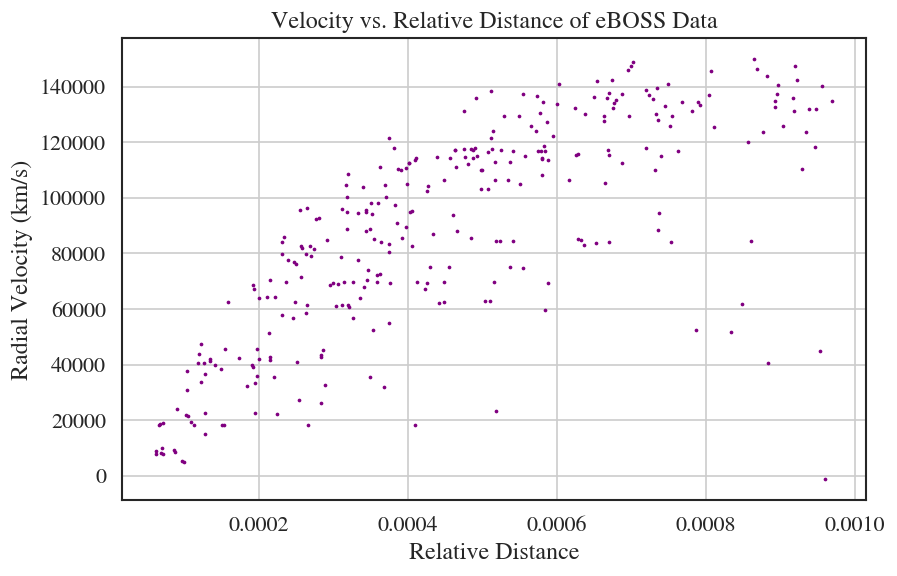

In [ ]:

# Plotting eBOSS data
plt.figure(figsize=(8, 5))
plt.scatter(
    distance_velocity_array[:, 0],
    distance_velocity_array[:, 1],
    s=1.5,
    color="purple",
)
plt.title("Velocity vs. Relative Distance of eBOSS Data")
plt.xlabel("Relative Distance")
plt.ylabel("Radial Velocity (km/s)")
plt.grid(True)
plt.show()

In [ ]:
# Loading the Abell 2199 dataset
obs_id2 = np.loadtxt("abell_2199.txt", dtype=str)

# Querying eBOSS for the 32 Abell 2199 galaxies, sending the data to an array
results_tables2 = []
for i in obs_id2:
    query_result2 = Observations.query_criteria(
        provenance_name="eBOSS", obs_id=i
    )
    results_tables2.append(query_result2)

# Stacking the data into one table
combined_results2 = vstack(results_tables2)

# Ensuring the length of the stacked table is 32
print(f"Length of Abell 2199 dataset = {len(combined_results2)}")


Length of Abell 2199 dataset = 32


In [ ]:
# Gathering and downloading full spectra files
products2 = Observations.get_product_list(combined_results2)
manifest2 = Observations.download_products(
    products2, mrp_only=True, verbose=False
)

# Writing data to an array
abell_array = []
for path in manifest2["Local Path"]:
    abell_array.append(fits.open(path))

# Checking the length of the array matches the dataset
print(f"Length of Abell 2199 array = {len(abell_array)}")

INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_10729-58248-0357/spec-10729-58248-0357.fits with expected size 864000. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_10729-58248-0657/spec-10729-58248-0657.fits with expected size 864000. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_10729-58248-0359/spec-10729-58248-0359.fits with expected size 864000. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0125/spec-6045-56072-0125.fits with expected size 1082880. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0162/spec-6045-56072-0162.fits with expected size 1082880. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0130/spec-6045-56072-0130.fits with expected size 1082880. [astroquery.query]
INFO: Found cached file ./mastDownload/SDSS/sdss_eboss_6045-56072-0167/spec-6045-56072-0167.fits with expected size 1082880. [astroqu

In [ ]:
# Sending redshift, error in redshift, and r-band magnitudes to arrays
z_val_abell = []
z_err_abell = []
r_flux_abell = []

for galaxy in abell_array:
    galaxy_z = galaxy[2].data["Z"]
    zerr = galaxy[2].data["Z_ERR"]
    spectroflux = galaxy[2].data["SPECTROFLUX"][:, 2]
    z_val_abell.append(galaxy_z)
    z_err_abell.append(zerr)
    r_flux_abell.append(spectroflux)

# Converting lists into arrays
z_val_abell = np.array(z_val_abell)
z_err_abell = np.array(z_err_abell)
r_flux_abell = np.array(r_flux_abell)

# Calculate relative distance
relative_distance_abell = 1 / np.sqrt(r_flux_abell)
new_relative_distance_abell = relative_distance_abell / 1e3  # kpc

# Filter out zeros
plot_array_abell = np.column_stack(
    (z_val_abell, new_relative_distance_abell, z_err_abell)
)
mask2 = ~np.isnan(plot_array_abell[:, 1])
new_array_abell = plot_array_abell[mask2]

# Calculate velocity
velocity_abell = []
velocity_err_abell = []
for i, j in zip(new_array_abell[:, 0], new_array_abell[:, 2]):
    v = c * (((1 + i) ** 2 - 1) / ((1 + i) ** 2 + 1))
    v_err = np.abs(((4 * c * (1 + i)) / ((1 + i) ** 2 + 1) ** 2)) * j
    velocity_abell.append(v)
    velocity_err_abell.append(v_err)

# Creating new array of distance, velocity, and error in velocity
distance_velocity_array_abell = np.column_stack(
    (new_array_abell[:, 1], velocity_abell, velocity_err_abell)
)


In [ ]:
# Sorting the Abell 2199 data to find closest galaxy
sorted_abell = np.argsort(distance_velocity_array_abell[:, 0])
sorted_abell_array = distance_velocity_array_abell[sorted_abell]

# Taking the first Abell 2199 galaxy and find the average, setting that to 1
d1_abell = sorted_abell_array[0][0]

# Normalize distances to d1_abell
norm_dist = distance_velocity_array[:, 0] / d1_abell
norm_dist_abell = distance_velocity_array_abell[:, 0] / d1_abell

# Distance to Abell 2199
distance = 128  # Mpc

In [ ]:
def fit_func(x,m,b):
    return m*x + b

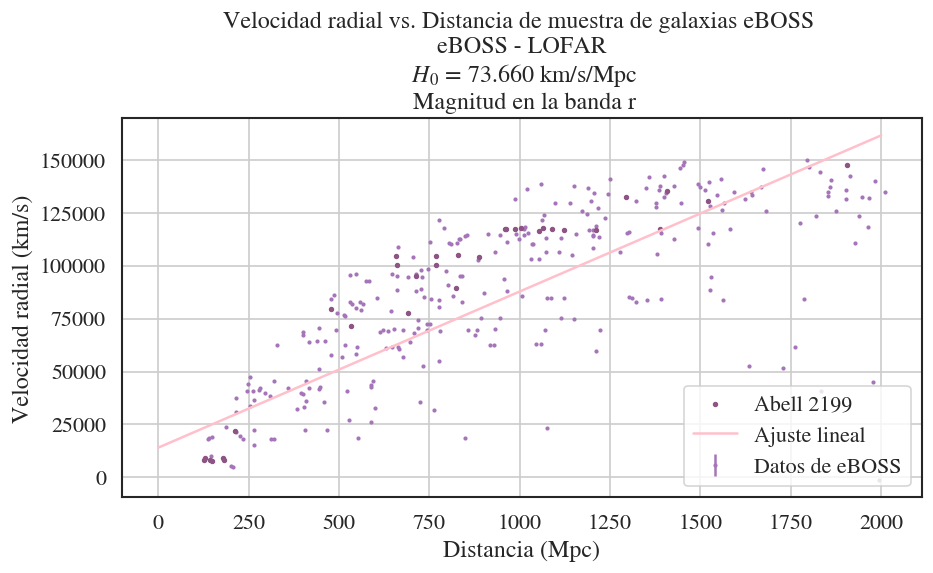

In [ ]:
#hacemos el fit con scipy
popt, covariance = curve_fit(
    fit_func,
    norm_dist * distance,
    distance_velocity_array[:,1],
    sigma = distance_velocity_array[:,2],
    absolute_sigma=True
)

m = popt[0] #pendiente aka cte hubble
b = popt[1] #intersección c eje y

#array para plotear el best-fitt
x_array = np.linspace(0,2000,200000)

#ploteamos
plt.figure(figsize=(8,5))
plt.errorbar(
    norm_dist * distance,
    distance_velocity_array[:, 1],
    yerr=distance_velocity_array[:, 2],
    ms=1.5,
    fmt="o",
    label="Datos de eBOSS",
    zorder=1,
    color = "#A675B9"
)
plt.scatter(
    norm_dist_abell * distance,
    distance_velocity_array_abell[:, 1],
    s=5,
    label="Abell 2199",
    color="#8E5483",
    zorder=2,
)
plt.plot(
    x_array,
    fit_func(x_array, m, b),
    label="Ajuste lineal",
    color='pink',
    zorder=3,
)
plt.ylabel("Velocidad radial (km/s)")
plt.xlabel("Distancia (Mpc)")
plt.title(
    f"Velocidad radial vs. Distancia de muestra de galaxias eBOSS \n eBOSS - LOFAR \n $H_{0}$ = {m:.3f} km/s/Mpc \n Magnitud en la banda r"
)
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
labels = ['Materia bariónica','Materia oscura fría','Energía oscura','Radiación y neutrinos']
sizes = [4.5,25,70,0.5]

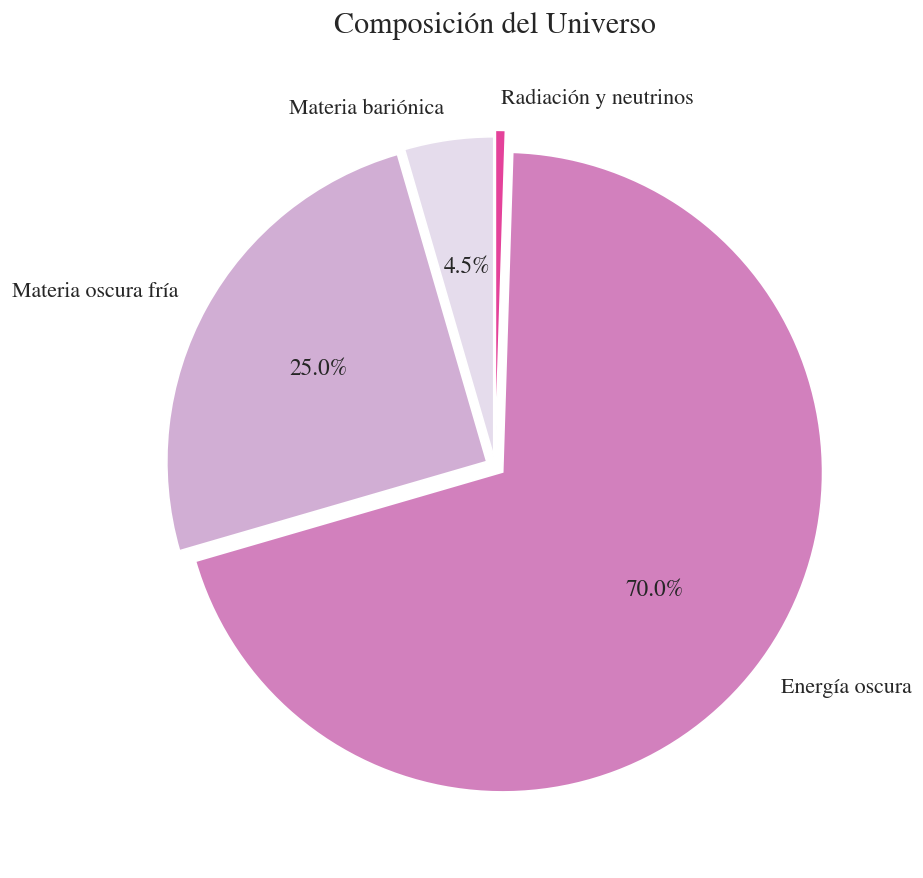

In [ ]:
sns.set_style("white")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14
})

plt.figure(figsize=(8,8))

explode = [0.03, 0.03, 0.03,0.05]
def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 1 else ''

plt.pie(
    sizes,
    labels=labels,
    colors=sns.color_palette("PuRd"),
    explode=explode,
    autopct=autopct_format,
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':1}
)

plt.title('Composición del Universo',
          fontsize=18,
          pad=20)

plt.tight_layout()
plt.show()


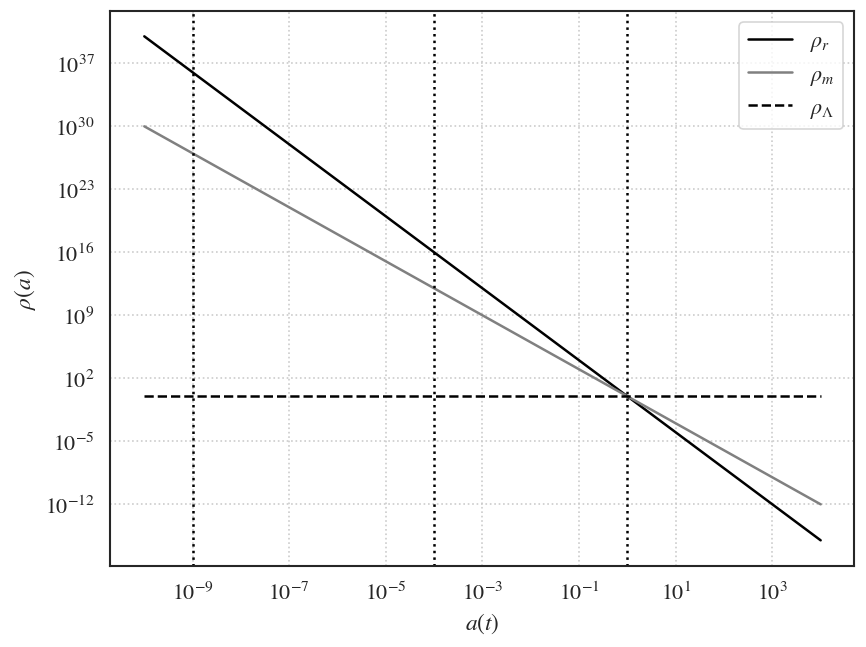

In [ ]:
# rango del factor de escala
a = np.logspace(-10, 4, 500)

# densidades normalizadas al valor actual
rho_r = a**(-4)
rho_m = a**(-3)
rho_L = np.ones_like(a)

plt.figure(figsize=(8,6))

plt.loglog(a, rho_r, color='black', label=r'$\rho_r$')
plt.loglog(a, rho_m, color='gray', label=r'$\rho_m$')
plt.loglog(a, rho_L, color='black', linestyle='--', label=r'$\rho_\Lambda$')

# etiquetas
plt.xlabel(r'$a(t)$', fontsize=14)
plt.ylabel(r'$\rho(a)$', fontsize=14)

# líneas verticales ejemplo
plt.axvline(1e-9, color='black', linestyle=':')
plt.axvline(1e-4, color='black', linestyle=':')
plt.axvline(1, color='black', linestyle=':')

plt.legend()

plt.grid(True, which="both", ls=":")

plt.show()


# Pipeline oficial (prueba)
Todo se iterará en un MCMC
1. MCMC propone w_i a través de GP (según el kernel y media)
2. interpolar w(z)
3. integrar
4. Calcular H(z)
5. Calcular distancias de BAO (segunda integral)
6. evaluar likelihood

In [ ]:
import scipy as sp

In [ ]:
def w_integral(z_emit,wp,zp):
    #w y z son puntos z_i w_i del mismo tamaño
    #primero interpolamos los w_i
    y = np.inetrp(z_emit,zp,wp) #array de la interpolación del sample de \vec(w)

    #paso 2: integramos

    g = (1.0 + y) / (1.0 + z_emit)

    I = sp.integrate.simpson(g,z_emit)

    f = np.exp(3*I)
    return f

#Hubble
def Hubble(z_emit,f,H_0 = 67.66, O_m = 0.30966,O_DE = 0.69034):
    H = H_0 * np.sqrt((O_m * (1+z_emit)**3 + O_DE*f))
    return H

# distancias



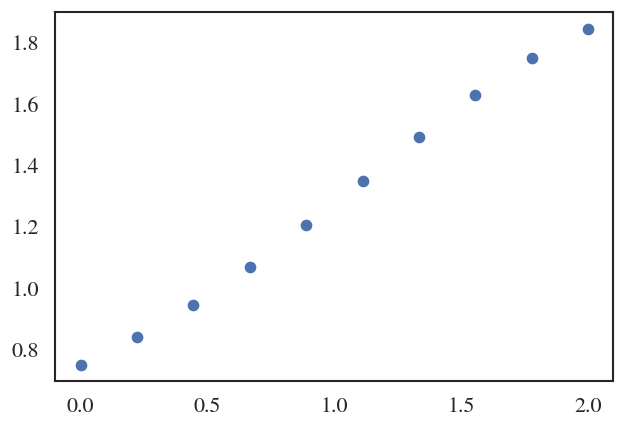

(10, 1)
[[0.75096195]
 [0.83927358]
 [0.94635481]
 [1.0702491 ]
 [1.20691367]
 [1.3505019 ]
 [1.49386414]
 [1.62919752]
 [1.74875722]
 [1.84553874]]


In [ ]:
# grid de nodos del GP
z_nodes = np.linspace(0, 2, 10)
#w_nodes = np.array([...])  # sample del MCMC

kernel_prior = 1 * kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) #Se escoge el kernel y los hiperparámetros iniciales
gp_prior = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
w_nodes = gaussian_process.sample_y(z_nodes.reshape(-1,1),1)
plt.scatter(z_nodes,w_nodes)
plt.show()
print(np.shape(w_nodes))
print(w_nodes)

In [ ]:
import camb
import numpy as np
from camb import model

# grid de nodos del GP
z_nodes = np.linspace(0, 2, 10)
#w_nodes = np.array([...])  # sample del MCMC

z_nodes = np.append(z_nodes, 10)
w_nodes = np.append(w_nodes, -1.0)

a_nodes = 1.0 / (1.0 + z_nodes)
order = np.argsort(a_nodes)
a_nodes = a_nodes[order]
w_nodes = w_nodes[order]


# CAMB parameters
pars = camb.CAMBparams()

pars.set_cosmology(H0=67.66, ombh2=0.0224, omch2=0.12)

# Esto es lo importante:
pars.set_dark_energy(w=-1.0)  # valor dummy

pars.DarkEnergy.set_w_a_table(a_nodes, w_nodes)

# ejecutar
results = camb.get_results(pars)

# obtener H(z)
z_eval = np.linspace(0,2,100)
Hz = results.hubble_parameter(z_eval)

# distancia angular
DA = results.angular_diameter_distance(z_eval)

In [ ]:
print("z_nodes shape:", z_nodes.shape)
print("w_nodes shape:", w_nodes.shape)
print("order shape:", order.shape)

z_nodes shape: (10,)
w_nodes shape: (1,)
order shape: (10,)
